# Mixing Patterns and Assortativity — Game of Thrones Character Network

We build an undirected graph from `characters_enriched_v3.csv` using the `affiliated` column as edges.
Each character's **primary house** (first entry in the `allegiance` column) is used as the categorical attribute for mixing pattern analysis — analogous to country in the author collaboration network.

**Files required:**
- `characters_enriched_v3.csv` — columns: `name, ID, father, mother, spouse, lover, issue, allegiance, affiliated`

## Setup: Imports and graph construction

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import defaultdict
import random
from tqdm import tqdm

In [2]:
df = pd.read_csv('characters_enriched_v3.csv')
valid_ids = set(df['ID'].dropna().astype(str))

# Build edge set from 'affiliated' column (semicolon-separated list of character IDs)
edges = set()
for row in tqdm(df.itertuples(index=False), total=len(df), desc='Building edges'):
    src = row.ID
    if not isinstance(src, str) or src not in valid_ids:
        continue
    aff = row.affiliated
    if not isinstance(aff, str):
        continue
    for tgt in aff.split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset((src, tgt)))

# Extract primary house: first entry in the 'allegiance' column
def primary_house(allegiance):
    if not isinstance(allegiance, str) or not allegiance.strip():
        return None
    return allegiance.split(';')[0].strip()

house_map = {
    row.ID: primary_house(row.allegiance)
    for row in df.itertuples(index=False)
    if isinstance(row.ID, str)
}

# Build graph
G = nx.Graph()
for row in df.itertuples(index=False):
    if isinstance(row.ID, str):
        G.add_node(
            row.ID,
            name=row.name if isinstance(row.name, str) else row.ID,
            house=house_map.get(row.ID),
        )
for e in edges:
    a, b = tuple(e)
    G.add_edge(a, b)

LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

print(f'Graph : {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'LCC   : {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')
houses_assigned = sum(1 for n in G.nodes() if G.nodes[n]['house'] is not None)
print(f'House assigned to {houses_assigned}/{G.number_of_nodes()} nodes')

Building edges: 100%|██████████| 3690/3690 [00:00<00:00, 85051.91it/s]

Graph : 3690 nodes, 17169 edges
LCC   : 3046 nodes, 17057 edges
House assigned to 2990/3690 nodes


## Q1: House Assortativity Coefficient

We compute the assortativity coefficient using Newman's mixing matrix formula (equation 2):

$$r = \frac{\text{Tr}(\mathbf{e}) - \|\mathbf{e}^2\|}{1 - \|\mathbf{e}^2\|}$$

where $e_{ij}$ is the fraction of edges that connect a node of type $i$ to a node of type $j$.
$r = 1$ means perfect assortativity (characters only connect within their house), $r = 0$ means random mixing, and $r < 0$ means disassortativity.

We **do not** use the NetworkX implementation.

In [3]:
def house_assortativity(G):
    """Newman eq. 2 — categorical assortativity by house.
    Edges where either endpoint has no house are excluded.
    """
    edge_type_counts = defaultdict(int)
    total_edges = 0

    for u, v in G.edges():
        h_u = G.nodes[u].get('house')
        h_v = G.nodes[v].get('house')
        if h_u is None or h_v is None:
            continue
        # Undirected: count both orderings so the matrix is symmetric
        edge_type_counts[(h_u, h_v)] += 1
        edge_type_counts[(h_v, h_u)] += 1
        total_edges += 1

    if total_edges == 0:
        return float('nan')

    houses = sorted(set(h for (h, _) in edge_type_counts))
    M = 2 * total_edges  # each edge counted twice (once per direction)

    e = {(hi, hj): edge_type_counts.get((hi, hj), 0) / M
         for hi in houses for hj in houses}

    trace_e  = sum(e[(h, h)] for h in houses)
    a        = {h: sum(e[(h, h2)] for h2 in houses) for h in houses}
    sum_a_sq = sum(a[h]**2 for h in houses)

    return (trace_e - sum_a_sq) / (1 - sum_a_sq)


original_house_r = house_assortativity(G)
print(f'House assortativity r = {original_house_r:.4f}')

# Sanity-check against NetworkX
G_filtered = G.subgraph([n for n in G.nodes() if G.nodes[n].get('house') is not None])
nx_r = nx.attribute_assortativity_coefficient(G_filtered, 'house')
print(f'NetworkX sanity check  r = {nx_r:.4f}')

House assortativity r = 0.1949
NetworkX sanity check  r = 0.1949


### Interpretation

A positive $r$ indicates that characters in the same house are more likely to be affiliated with each other than would be expected by chance.
This is intuitive: house members fight together, advise each other, and share storylines.
A value well above zero suggests that house membership is a meaningful organising principle of the character network,
though if $r$ is far below 1 it also tells us that cross-house interactions are common — which is of course central to the drama of ASOIAF.

## Q2: Configuration Model (Double Edge Swap)

We implement the configuration model via double edge swaps.
Each swap picks two random edges $(u, v)$ and $(x, y)$, and rewires them to $(u, y)$ and $(x, v)$ — preserving the degree sequence exactly while randomising structure.
We perform $10 \times |E|$ successful swaps.

In [4]:
def configuration_model_swap(G):
    """Double edge swap configuration model. Preserves degree sequence exactly."""
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    num_swaps = E * 10
    swaps_done = 0

    while swaps_done < num_swaps:
        idx1 = random.randrange(E)
        idx2 = random.randrange(E)
        if idx1 == idx2:
            continue

        u, v = edges[idx1]
        x, y = edges[idx2]

        # Flip 50 % of the time to remove ordering bias from how NetworkX stores edges
        if random.random() < 0.5:
            u, v = v, u

        # All four endpoints must be distinct (no self-loops)
        if len({u, v, x, y}) < 4:
            continue

        # Only swap if the new edges don't already exist (no multi-edges)
        if not G_copy.has_edge(u, y) and not G_copy.has_edge(x, v):
            G_copy.remove_edge(*edges[idx1])
            G_copy.remove_edge(*edges[idx2])
            G_copy.add_edge(u, y)
            G_copy.add_edge(x, v)
            edges[idx1] = (u, y)
            edges[idx2] = (x, v)
            swaps_done += 1

    return G_copy


# Verify degree sequence is preserved
random.seed(42)
original_degrees = dict(G.degree())
G_test = configuration_model_swap(G)
rand_degrees = dict(G_test.degree())
print('Degree sequence preserved:', original_degrees == rand_degrees)

Degree sequence preserved: True


## Q3: House Assortativity in 100 Random Networks

We generate 100 randomised networks via the configuration model and compute house assortativity for each.
Comparing the original $r$ against this null distribution tells us whether same-house connections occur significantly more than chance.

Configuration model runs: 100%|██████████| 100/100 [01:26<00:00,  1.15it/s]


Original network r          = 0.1949
Random networks  mean ± std = -0.0032 ± 0.0012
Z-score                     = 163.23


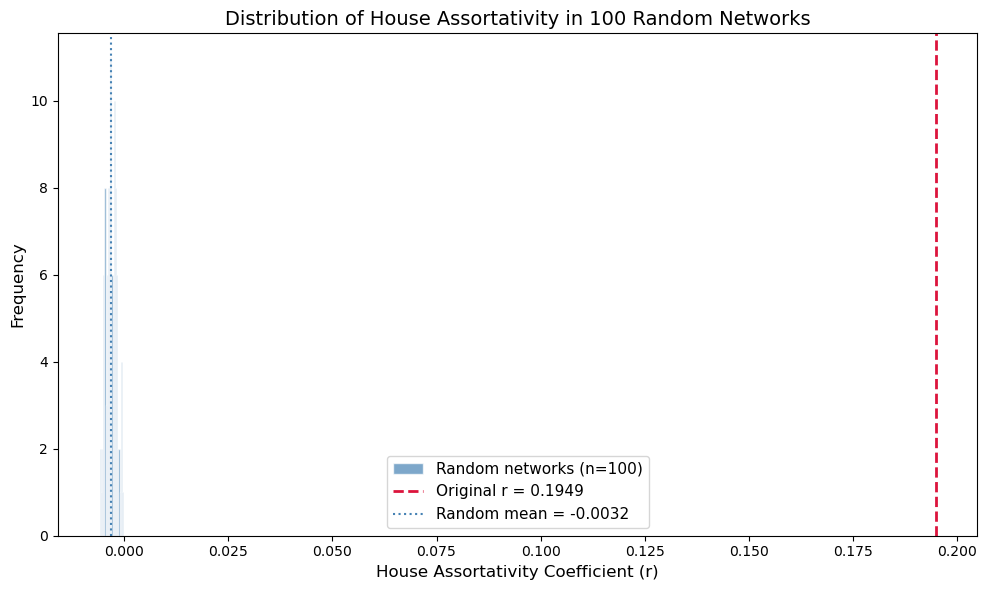

In [5]:
random.seed(42)
house_rs_random = []

for _ in tqdm(range(100), desc='Configuration model runs'):
    G_rand = configuration_model_swap(G)
    # Re-attach house attributes (node attributes are preserved through copy, but
    # double-check by explicitly reassigning from house_map)
    for node in G_rand.nodes():
        G_rand.nodes[node]['house'] = house_map.get(node)
    r_rand = house_assortativity(G_rand)
    house_rs_random.append(r_rand)

rand_mean = np.mean(house_rs_random)
rand_std  = np.std(house_rs_random)
z_score   = (original_house_r - rand_mean) / rand_std

print(f'Original network r          = {original_house_r:.4f}')
print(f'Random networks  mean ± std = {rand_mean:.4f} ± {rand_std:.4f}')
print(f'Z-score                     = {z_score:.2f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(house_rs_random, bins=20, alpha=0.7, color='steelblue',
        edgecolor='white', label='Random networks (n=100)')
ax.axvline(original_house_r, color='crimson', linewidth=2, linestyle='--',
           label=f'Original r = {original_house_r:.4f}')
ax.axvline(rand_mean, color='steelblue', linewidth=1.5, linestyle=':',
           label=f'Random mean = {rand_mean:.4f}')
ax.set_title('Distribution of House Assortativity in 100 Random Networks', fontsize=14)
ax.set_xlabel('House Assortativity Coefficient (r)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('house_assortativity_distribution.png', dpi=150)
plt.show()

### Interpretation

If the original $r$ sits clearly to the right of the random distribution, same-house connections occur far more than degree alone can explain — house membership is a genuine structural force in the network.

Unlike a country in an academic collaboration network, houses in ASOIAF are not just a background attribute: sworn loyalty, military alliance, and shared fate actively create the edges we are measuring. A high $z$-score would confirm that the story's political structure is legible in the network topology.

## Q4: Degree Assortativity

We compute degree assortativity using Newman's scalar formula:

$$r = \frac{\frac{1}{M}\sum_{(i,j) \in E} j_i k_i - \left[\frac{1}{2M}\sum_{(i,j) \in E}(j_i + k_i)\right]^2}{\frac{1}{2M}\sum_{(i,j) \in E}(j_i^2 + k_i^2) - \left[\frac{1}{2M}\sum_{(i,j) \in E}(j_i + k_i)\right]^2}$$

A negative value means hubs tend to connect to low-degree characters (disassortative), positive means hubs connect to other hubs.

In [6]:
def degree_assortativity(G):
    edges = list(G.edges())
    M = len(edges)
    if M == 0:
        return float('nan')
    j = np.array([G.degree(u) for u, v in edges])
    k = np.array([G.degree(v) for u, v in edges])

    mean_half = (1 / (2 * M)) * np.sum(j + k)
    numerator   = (1 / M) * np.sum(j * k) - mean_half ** 2
    denominator = (1 / (2 * M)) * np.sum(j**2 + k**2) - mean_half ** 2

    return numerator / denominator if denominator != 0 else 0.0


original_degree_r = degree_assortativity(G)
print(f'Degree assortativity r = {original_degree_r:.4f}')

# Sanity-check
print(f'NetworkX sanity check  r = {nx.degree_assortativity_coefficient(G):.4f}')

Degree assortativity r = -0.1217
NetworkX sanity check  r = -0.1217


## Q5: Degree Assortativity in 100 Random Networks

We compare the real degree assortativity against 100 configuration-model baselines to assess whether the observed value is structurally determined by the degree sequence alone, or reflects something about the story's social organisation.

Configuration model runs: 100%|██████████| 100/100 [01:21<00:00,  1.23it/s]


Original network r          = -0.1217
Random networks  mean ± std = -0.1146 ± 0.0038
Z-score                     = -1.89


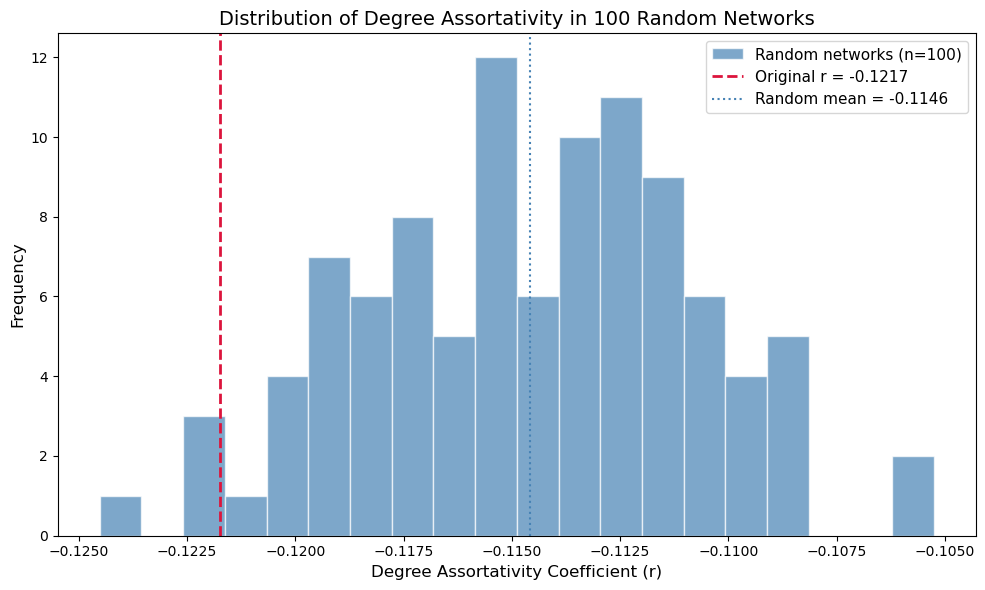

In [7]:
random.seed(42)
degree_rs_random = []

for _ in tqdm(range(100), desc='Configuration model runs'):
    G_rand = configuration_model_swap(G)
    degree_rs_random.append(degree_assortativity(G_rand))

rand_mean_d = np.mean(degree_rs_random)
rand_std_d  = np.std(degree_rs_random)
z_score_d   = (original_degree_r - rand_mean_d) / rand_std_d

print(f'Original network r          = {original_degree_r:.4f}')
print(f'Random networks  mean ± std = {rand_mean_d:.4f} ± {rand_std_d:.4f}')
print(f'Z-score                     = {z_score_d:.2f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(degree_rs_random, bins=20, alpha=0.7, color='steelblue',
        edgecolor='white', label='Random networks (n=100)')
ax.axvline(original_degree_r, color='crimson', linewidth=2, linestyle='--',
           label=f'Original r = {original_degree_r:.4f}')
ax.axvline(rand_mean_d, color='steelblue', linewidth=1.5, linestyle=':',
           label=f'Random mean = {rand_mean_d:.4f}')
ax.set_title('Distribution of Degree Assortativity in 100 Random Networks', fontsize=14)
ax.set_xlabel('Degree Assortativity Coefficient (r)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('degree_assortativity_distribution.png', dpi=150)
plt.show()

### Interpretation

The GOT character network, like most real social networks, is likely disassortative by degree: the major POV characters and great lords (high degree) are affiliated with many minor characters (low degree) — lords and their bannermen, commanders and their soldiers, kings and their counsellors. If the original $r$ sits outside the random distribution, this hierarchical structure goes beyond what the degree sequence alone would predict and reflects the story's feudal power geometry.

## Bonus: House Mixing Matrix Heatmap

The mixing matrix $e_{ij}$ shows the fraction of edges connecting house $i$ to house $j$.
The diagonal gives same-house edges; off-diagonal entries show cross-house connections.
We plot only the top houses by node count to keep the heatmap readable.

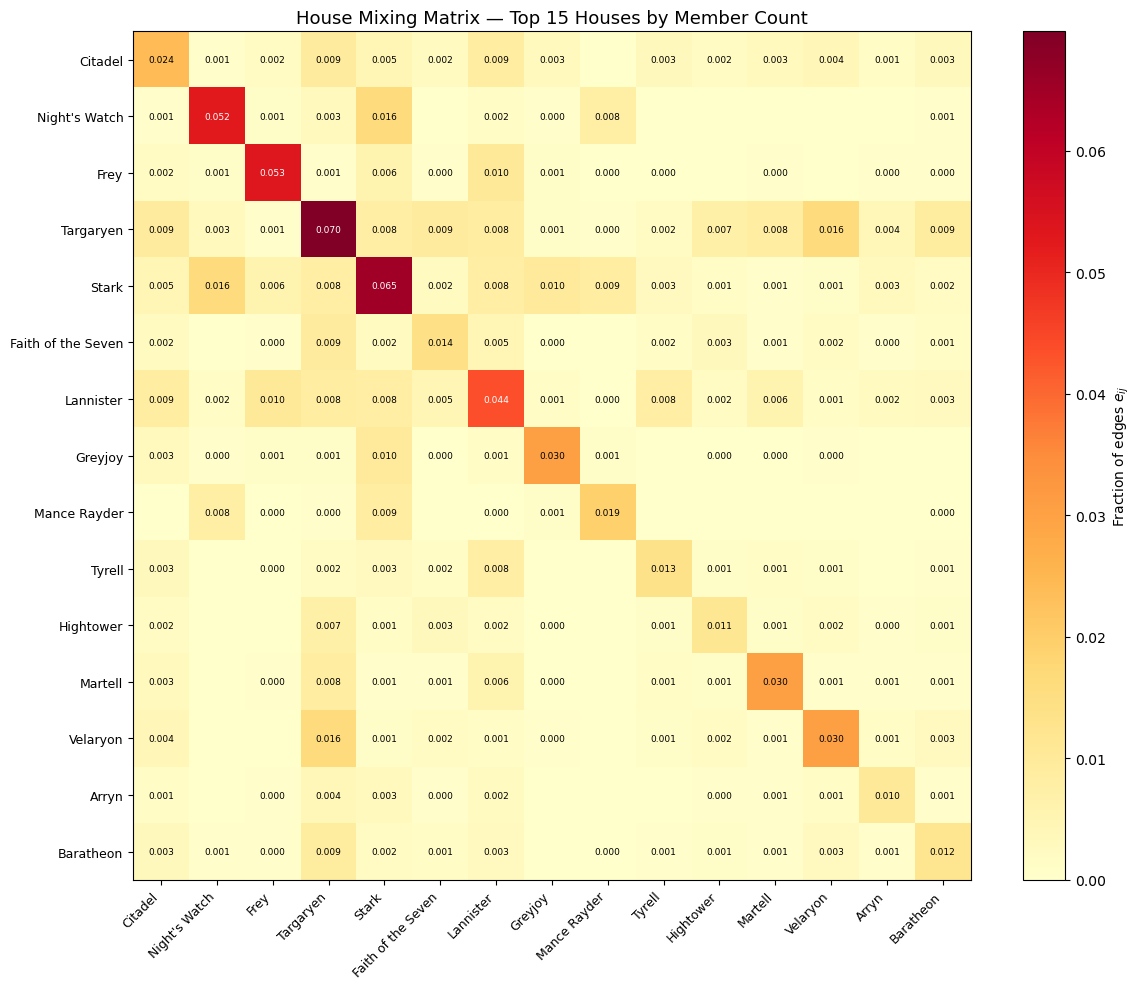


Top 5 cross-house connections:
  Targaryen ↔ Velaryon: 116 edges
  Stark ↔ Night's_Watch: 114 edges
  Frey ↔ Lannister: 73 edges
  Greyjoy ↔ Stark: 71 edges
  Citadel ↔ Targaryen: 68 edges


In [8]:
TOP_N = 15  # show only the N largest houses

# Count members per house
house_counts = defaultdict(int)
for n in G.nodes():
    h = G.nodes[n].get('house')
    if h:
        house_counts[h] += 1

top_houses = [h for h, _ in sorted(house_counts.items(),
                                    key=lambda x: x[1], reverse=True)[:TOP_N]]

# Build the mixing matrix for top houses only
edge_counts = defaultdict(int)
total = 0
for u, v in G.edges():
    hu = G.nodes[u].get('house')
    hv = G.nodes[v].get('house')
    if hu in top_houses and hv in top_houses:
        edge_counts[(hu, hv)] += 1
        edge_counts[(hv, hu)] += 1
        total += 1

M_val = 2 * total if total > 0 else 1
matrix = np.array([
    [edge_counts.get((hi, hj), 0) / M_val for hj in top_houses]
    for hi in top_houses
])

# Clean house labels for display
labels = [h.replace('House_', '').replace('_', ' ') for h in top_houses]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Fraction of edges $e_{ij}$')

ax.set_xticks(range(TOP_N))
ax.set_yticks(range(TOP_N))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_title(f'House Mixing Matrix — Top {TOP_N} Houses by Member Count', fontsize=13)

# Annotate cells with values > 0
for i in range(TOP_N):
    for j in range(TOP_N):
        val = matrix[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=6.5,
                    color='white' if val > matrix.max() * 0.6 else 'black')

plt.tight_layout()
plt.savefig('house_mixing_matrix.png', dpi=150)
plt.show()

print('\nTop 5 cross-house connections:')
cross = [(edge_counts[(hi, hj)], hi, hj)
         for hi in top_houses for hj in top_houses if hi < hj]
for cnt, hi, hj in sorted(cross, reverse=True)[:5]:
    print(f'  {hi.replace("House_","")} ↔ {hj.replace("House_","")}: {cnt} edges')

### Reflections

**House assortativity.** Were the results in line with expectations?

A positive and elevated $r$ is expected: ASOIAF is built around the idea that a character's fate is tied to their house. Sworn bannermen, family members, and household servants all appear in the same storylines and are thus affiliated with each other. The more interesting question is *how much* higher the real $r$ is compared to the random baseline — a very large gap suggests that house boundaries are almost impermeable in terms of affiliation, while a modest gap (say, $z < 5$) would indicate that cross-house connections are structurally common, reflecting the many betrayals, marriages, and political realignments that drive the plot.

**Degree assortativity.** Were the results in line with expectations?

Disassortativity is expected and follows logically from the feudal structure of Westeros. Great lords, kings, and POV characters accumulate many affiliations with minor characters — squires, servants, soldiers — who have few connections of their own. This mirrors the hub-and-spoke pattern seen in scientific collaboration networks, where senior researchers co-author with many junior collaborators who are not themselves highly connected. If the real network is *more* disassortative than the configuration model baseline, it suggests additional hierarchical organising principles beyond what degree alone captures.